In [13]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt


In [14]:
# Define constants/boundaries

GRID_SIZE = 5
START = (0, 0)
GOAL = (4, 4)
MAX_STEPS = 50

In [15]:
# Actions

ACTIONS = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1)
}

In [16]:
# Agent and grid definitions

class GridWorld:
    def __init__(self):
        self.reset()

    def reset(self):
        self.agent_pos = START
        self.steps = 0
        self.done = False
        self.path = [self.agent_pos]
        return self.agent_pos

    def step(self, action):
        if self.done:
            return self.agent_pos, 0, self.done

        dx, dy = ACTIONS[action]
        x, y = self.agent_pos
        nx, ny = x + dx, y + dy

        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
            self.agent_pos = (nx, ny)

        self.steps += 1
        self.path.append(self.agent_pos)

        reward = -1
        if self.agent_pos == GOAL:
            reward = 10
            self.done = True
        elif self.steps >= MAX_STEPS:
            self.done = True

        return self.agent_pos, reward, self.done


In [17]:
# Manual policy hardcoded

def manual_policy(position):
    x, y = position
    if y < 4:
        return "RIGHT"
    elif x < 4:
        return "DOWN"
    else:
        return None

Total reward: 3
Steps taken: 8
9
[[0.8 0.5 0.5 0.5 0.5]
 [0.  0.  0.  0.  0.5]
 [0.  0.  0.  0.  0.5]
 [0.  0.  0.  0.  0.5]
 [0.  0.  0.  0.  1. ]]


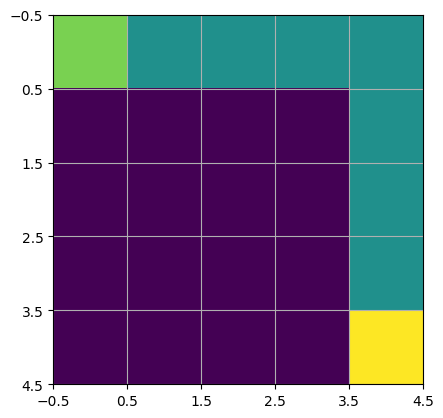

In [35]:
# Run simulation till not done, keep track of reward

env = GridWorld()
state = env.reset()
total_reward = 0

while not env.done:
    action = manual_policy(state)
    if action is None:
        break
    state, reward, done = env.step(action)
    total_reward += reward

print("Total reward:", total_reward)
print("Steps taken:", env.steps)

grid = np.zeros ( ( GRID_SIZE, GRID_SIZE ) )

for x, y in env.path:
    grid[x, y] = 0.5

grid[START] = 0.8
grid[GOAL] = 1.0

print ( grid )
plt.imshow(grid, interpolation='none')
plt.xticks(np.arange(-0.5, 5, 1))
plt.yticks(np.arange(-0.5, 5, 1))
plt.grid(True)
plt.grid(True)
plt.show()
